# Simple joint inversion of gravity and mag

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import harmonica as hm
import bordado as bd
import discretize

import simpeg
from simpeg.potential_fields import gravity
from simpeg.potential_fields import magnetics

import inversion_ideas as ii

## Generate synthetic data for gravity and magnetic fields

In [2]:
class Sphere:
    def __init__(
        self, radius: float, center: tuple[float, float, float], density: float, susceptibility: float
    ):
        self.radius = radius
        self.center = center
        self.density = density
        self.susceptibility = susceptibility

    @property
    def mass(self):
       return self.volume * self.density

    @property
    def volume(self):
       return 4 / 3 * np.pi * self.radius ** 3

    def gravity(self, coordinates, field="g_z"):
        """
        Gravity field of the sphere in mGal or Eotvos.
        """
        return hm.point_gravity(coordinates, self.center, self.mass, field=field)

    def magnetic(self, coordinates, inducing_field):
        """
        Mangetic field of the sphere in nT.

        The inducing_field is the vector components in nT.
        """
        from scipy.constants import mu_0
        b0_field = np.asarray(inducing_field) * 1e-9 # convert to SI units
        h0_field = b0_field / mu_0
        magnetic_moment = self.volume * self.susceptibility * h0_field
        return hm.dipole_magnetic(coordinates, self.center, magnetic_moment, field="b")

In [3]:
sphere = Sphere(radius=40, center=(0, 0, -50), density=200.0, susceptibility=0.2)

region = (-100, 100, -100, 100)
shape = (101, 101)
height = 30.0
coordinates = bd.grid_coordinates(region=region, shape=shape, non_dimensional_coords=height)
g_downwards = sphere.gravity(coordinates)

# Invert sign of gz so it points upwards (following simpeg convention)
gz = -g_downwards

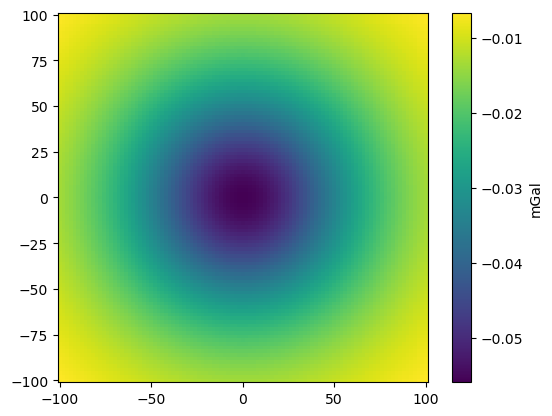

In [4]:
tmp = plt.pcolormesh(*coordinates[:2], gz)
plt.gca().set_aspect("equal")
plt.colorbar(tmp, label="mGal")
plt.show()

In [5]:
intensity = 55_000.0
inc, dec = 72, 12
inducing_field = hm.magnetic_angles_to_vec(intensity, inc, dec)

b_field = sphere.magnetic(coordinates, inducing_field)
tmi = hm.total_field_anomaly(b_field, inc, dec)

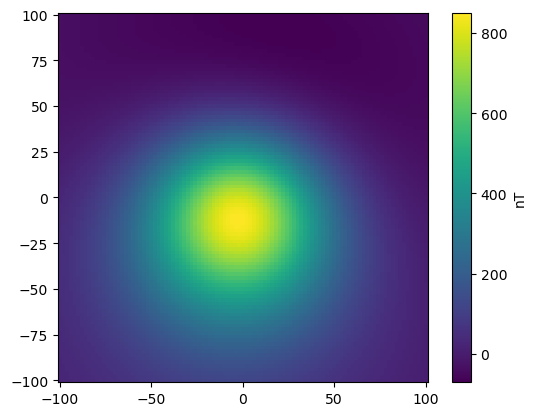

In [6]:
tmp = plt.pcolormesh(*coordinates[:2], tmi)
plt.gca().set_aspect("equal")
plt.colorbar(tmp, label="nT")
plt.show()

Add noise to them

In [7]:
rng = np.random.default_rng(seed=42)

In [8]:
gz_error = 1/100 * np.max(np.abs(gz))
gz += rng.normal(scale=gz_error, size=gz.shape)

In [9]:
tmi_error = 1/100 * np.max(np.abs(tmi))
tmi += rng.normal(scale=tmi_error, size=tmi.shape)

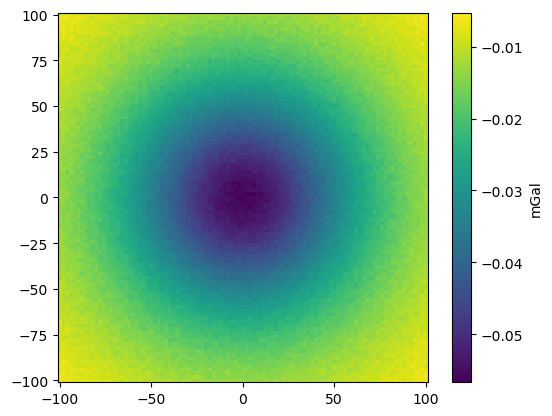

In [10]:
tmp = plt.pcolormesh(*coordinates[:2], gz)
plt.gca().set_aspect("equal")
plt.colorbar(tmp, label="mGal")
plt.show()

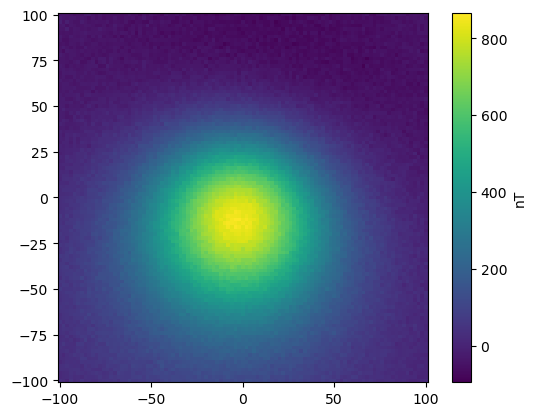

In [11]:
tmp = plt.pcolormesh(*coordinates[:2], tmi)
plt.gca().set_aspect("equal")
plt.colorbar(tmp, label="nT")
plt.show()

## Define mesh and simulations

In [12]:
# h = [(5.0, 40)]
h = [(10.0, 20)]
mesh = discretize.TensorMesh(h=[h, h, h], origin="CCN")
mesh

TensorMesh: 8,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     20       -100.00        100.00     10.00     10.00    1.00
   y     20       -100.00        100.00     10.00     10.00    1.00
   z     20       -200.00          0.00     10.00     10.00    1.00

### Gravity simulation

In [13]:
locations = np.vstack(tuple(c.ravel() for c in coordinates)).T
receivers = gravity.Point(locations, components="gz")
source = gravity.SourceField(receiver_list=[receivers])
survey = gravity.Survey(source)

In [14]:
gravity_simulation_simpeg = gravity.Simulation3DIntegral(
    mesh, survey=survey, rhoMap=simpeg.maps.IdentityMap(mesh), engine="choclo"
)

In [15]:
gravity_simulation = ii.wrap_simulation(gravity_simulation_simpeg, store_jacobian=True)
gravity_simulation

In [16]:
gravity_model = np.ones(mesh.n_cells)

In [17]:
gravity_simulation(gravity_model)

array([-1.0973378, -1.1180236, -1.1385899, ..., -1.1385899, -1.1180238,
       -1.097338 ], shape=(10201,), dtype=float32)

### Magnetic simulation

In [18]:
locations = np.vstack(tuple(c.ravel() for c in coordinates)).T
receivers = magnetics.Point(locations, components="tmi")
source = magnetics.UniformBackgroundField(receiver_list=[receivers], amplitude=intensity, inclination=inc, declination=dec)
survey = magnetics.Survey(source)

In [19]:
mag_simulation_simpeg = magnetics.Simulation3DIntegral(
    mesh, survey=survey, chiMap=simpeg.maps.IdentityMap(mesh), engine="choclo"
)

In [20]:
magnetic_simulation = ii.wrap_simulation(mag_simulation_simpeg, store_jacobian=True)
magnetic_simulation

In [21]:
sus_model = np.ones(mesh.n_cells)

In [22]:
magnetic_simulation(sus_model)

array([ 8341.44   ,  8712.186  ,  9077.091  , ...,  -908.41644,
       -1021.27167, -1133.554  ], shape=(10201,), dtype=float32)

## Build inversion

In [23]:
wires = ii.Wires(density=gravity_simulation.n_params, susceptibility=magnetic_simulation.n_params)
wires

In [24]:
gz_data = gz.ravel()
gz_uncertainties = np.ones_like(gz_data) * gz_error
gravity_data_misfit = ii.DataMisfit(
    gz_data, gz_uncertainties, simulation=gravity_simulation, model_slice=wires.density
)

tmi_data = tmi.ravel()
tmi_uncertainties = np.ones_like(tmi_data) * tmi_error
magnetic_data_misfit = ii.DataMisfit(
    tmi_data, tmi_uncertainties, simulation=magnetic_simulation, model_slice=wires.susceptibility
)

data_misfit = 0.5 * gravity_data_misfit + 0.5 * magnetic_data_misfit

In [25]:
## Density regularizations
initial_model = np.zeros(gravity_simulation.n_params)
sensitivity_weights = ii.utils.get_sensitivity_weights(
    gravity_simulation.jacobian(initial_model),
    data_weights=gravity_data_misfit.weights_matrix,
    volumes=mesh.cell_volumes,
)
alpha_s = 0.06
gravity_regularization = (
    alpha_s * ii.Smallness(
        mesh, cell_weights=sensitivity_weights, model_slice=wires.density
    ).set_name("Gs")
    +
    sum(
        ii.Flatness(
            mesh, direction=direction, cell_weights=sensitivity_weights, model_slice=wires.density
        ).set_name(f"G{direction}")
        for direction in ("x", "y", "z")
    )
).flatten()

gravity_regularization

0.06 φGs(m) + φGx(m) + φGy(m) + φGz(m)

In [26]:
## Magnetic regularizations
initial_model = np.zeros(magnetic_simulation.n_params)
sensitivity_weights = ii.utils.get_sensitivity_weights(
    magnetic_simulation.jacobian(initial_model),
    data_weights=magnetic_data_misfit.weights_matrix,
    volumes=mesh.cell_volumes,
)
alpha_s = 0.06
magnetic_regularization = (
    alpha_s * ii.Smallness(
        mesh, cell_weights=sensitivity_weights, model_slice=wires.susceptibility
    ).set_name("Ms")
    +
    sum(
        ii.Flatness(
            mesh, direction=direction, cell_weights=sensitivity_weights, model_slice=wires.susceptibility
        ).set_name(f"M{direction}") 
        for direction in ("x", "y", "z")
    )
).flatten()
magnetic_regularization

0.06 φMs(m) + φMx(m) + φMy(m) + φMz(m)

In [27]:
model_norm = gravity_regularization + magnetic_regularization

beta_0 = 1e3
regularization = beta_0 * model_norm
regularization

1000. [[0.06 φGs(m) + φGx(m) + φGy(m) + φGz(m)] + [0.06 φMs(m) + φMx(m) + φMy(m) + φMz(m)]]

In [28]:
phi = data_misfit + regularization
phi

[0.5 φd(m) + 0.5 φd(m)] + 1000. [[0.06 φGs(m) + φGx(m) + φGy(m) + φGz(m)] + [0.06 φMs(m) + φMx(m) + φMy(m) + φMz(m)]]

In [29]:
initial_model_dict = {
    "density": np.zeros(wires.density.size),
    "susceptibility": np.zeros(wires.susceptibility.size),
}
initial_model = wires.dict_to_array(initial_model_dict)
initial_model.size

16000

In [30]:
phi(initial_model)

np.float64(15939460.971042376)

In [31]:
phi.gradient(initial_model)

array([-60772.55215155, -62874.73765604, -64835.60029641, ...,
        51267.82085311,  46856.48024349,  38451.26128869], shape=(16000,))

In [32]:
phi.hessian(initial_model)

<16000x16000 _SumLinearOperator with dtype=float64>

In [33]:
# Define directives: beta-cooling schedule
directives = [
    ii.MultiplierCooler(regularization, cooling_factor=2)
]

# Define stopping condition for the inversion:
# the two data misfits reach the chi target of 1.0
stopping_criterion = (
    ii.conditions.ChiTarget(gravity_data_misfit)
    & ii.conditions.ChiTarget(magnetic_data_misfit)
)

# Define inversion log
inversion_log = ii.InversionLogRich({
    "iter": lambda iteration, _: iteration,
    "phi_d_gravity": lambda iteration, model: gravity_data_misfit(model),
    "chi(phi_d_gravity)": lambda iteration, model: gravity_data_misfit.chi_factor(model),
    "phi_d_mag": lambda iteration, model: magnetic_data_misfit(model),
    "chi(phi_d_mag)": lambda iteration, model: magnetic_data_misfit.chi_factor(model),
    "beta": lambda _, __: regularization.multiplier,
    "phi_m": lambda iteration, model: model_norm(model),
})

inversion = ii.Inversion(
    phi, 
    initial_model,
    minimizer=ii.minimize.conjugate_gradient,
    directives=directives,
    stopping_criterion=stopping_criterion,
    log=inversion_log,
    cache_models=True,
)

In [34]:
inversion.run()

Output()

array([-0.00555857, -0.00483852, -0.00405656, ..., -0.00884488,
        0.01172493, -0.02781412], shape=(16000,))

In [35]:
inverted_model = inversion.models[-1]

inverted_density = wires.density.extract(inverted_model)
inverted_susceptibility = wires.susceptibility.extract(inverted_model)

AttributeError: Inversion doesn't have cached models since `cache_model` is `False`.